<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue; text-align: left;">
 Empirical Path Loss Models: CV, Generalization, and Residual Analysis
</p>


#### Notebook scope
This notebook keeps the empirical path-loss comparison, but evaluates it with the same train/test and 5-fold protocol used by the ML pipelines.

The split-level artifacts are saved per empirical PLM, not only for the selected model:
- `Residuals/residuals_PLM_<MODEL>_oof.csv`
- `Residuals/residuals_PLM_<MODEL>_test.csv`
- `Models/plm_<MODEL>_model.json`

The generalization result is displayed as a notebook table only; it is not saved as a CSV. The fold-level CV diagnostics are used to compute OOF predictions but are not exported.

Implementation notes:
- FSPL is evaluated with the row-level frequency, using the exact Friis/free-space expression.
- Motley-Keenan/Average Wall Model is implemented as FSPL plus fitted wall-loss coefficients and no extra intercept.
- COST 231 Multi-Wall is implemented as FSPL plus a fitted constant loss and fitted wall-loss coefficients; the floor term is omitted because this dataset is single-floor.
- ITU-R P.1238 uses `20 log10(f_MHz) + N log10(d_m) + Lf(n) - 28`; `N` is a distance power-loss coefficient in dB/decade, not the path-loss exponent itself. The equivalent exponent is `N / 10`.

Formula references used for this implementation:
- ITU-R P.1238-11: https://www.itu.int/dms_pubrec/itu-r/rec/p/R-REC-P.1238-11-202109-S%21%21PDF-E.pdf
- COST multi-wall form: https://2021.help.altair.com/2021.1/winprop/topics/winprop/user_guide/propagation_methods/propgation_models_indoor_mw.htm


#### Imports and paths


In [52]:
# Core utilities, data wrangling, modeling, metrics, and plotting

import json
import os
import time
from math import sqrt

# Keep BLAS thread use predictable; this notebook loops over small linear fits.
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["NUMEXPR_MAX_THREADS"] = "1"

import numpy as np
import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import norm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

TRAIN_CSV = "Data_Files/train.csv"
TEST_CSV = "Data_Files/test.csv"
FOLDS_NPY = "Data_Files/train_folds.npy"
FULL_CSV = "Data_Files/cleaned_dataset_per_device.csv"

MODELS_DIR = "Models"
FIGURES_DIR = "Figures"
RESIDUALS_DIR = "Residuals"

for directory in [MODELS_DIR, FIGURES_DIR, RESIDUALS_DIR]:
    os.makedirs(directory, exist_ok=True)

FIGURE_PATH = os.path.join(FIGURES_DIR, "average_&_empiricalfits_&_CDFvShadow.png")

RANDOM_STATE = 42

#### Data loading and split validation


In [53]:
# Load the full cleaned dataset for empirical plots and the common train/test split for evaluation.
df_full = pd.read_csv(FULL_CSV)
df_train = pd.read_csv(TRAIN_CSV)
df_test = pd.read_csv(TEST_CSV)
fold_assignments = np.load(FOLDS_NPY)

# Harmonize target naming across the original empirical dataset and prepared ML splits.
df_full = df_full.rename(columns={"exp_pl": "PL"}).copy()

target_col = "PL"
metadata_cols = [
    "time", "device_id", "distance", "frequency", "c_walls", "w_walls",
    "co2", "humidity", "pm25", "pressure", "temperature", "snr",
]
model_input_cols = ["distance", "frequency", "c_walls", "w_walls"]
required_eval_cols = [target_col, *metadata_cols]
required_full_cols = [target_col, *metadata_cols]

missing_train = [c for c in required_eval_cols if c not in df_train.columns]
missing_test = [c for c in required_eval_cols if c not in df_test.columns]
missing_full = [c for c in required_full_cols if c not in df_full.columns]

if missing_train or missing_test or missing_full:
    raise ValueError(
        f"Missing columns | train: {missing_train} | test: {missing_test} | full: {missing_full}"
    )

if len(fold_assignments) != len(df_train):
    raise ValueError(
        f"Fold vector length {len(fold_assignments)} does not match train rows {len(df_train)}."
    )

fold_ids = sorted(np.unique(fold_assignments[fold_assignments >= 0]).astype(int).tolist())
if len(fold_ids) != 5:
    print(f"Warning: expected 5 CV folds, found {len(fold_ids)} folds: {fold_ids}")
else:
    print(f"Using {len(fold_ids)} predefined time-aware CV folds: {fold_ids}")

fold_sizes = pd.Series(fold_assignments).value_counts().sort_index().rename_axis("fold").reset_index(name="n_rows")
display(fold_sizes)

X_train = df_train[model_input_cols].copy()
y_train = df_train[target_col].astype(float).to_numpy()
X_test = df_test[model_input_cols].copy()
y_test = df_test[target_col].astype(float).to_numpy()
X_full = df_full[model_input_cols].copy()
y_full = df_full[target_col].astype(float).to_numpy()

print(f"Full rows: {len(df_full):,} | Train rows: {len(df_train):,} | Test rows: {len(df_test):,}")
display(df_full[metadata_cols + [target_col]].head())

Using 5 predefined time-aware CV folds: [0, 1, 2, 3, 4]


,fold,n_rows
0,0,554543
1,1,277271
2,2,277271
3,3,277271
4,4,277271


Full rows: 2,079,534 | Train rows: 1,663,627 | Test rows: 415,907


,time,device_id,distance,frequency,c_walls,w_walls,co2,humidity,pm25,pressure,temperature,snr,PL
0,2024-10-01 00:01:07.420593+00:00,ED5,40,868.1,2,2,440.0,45.46,0.46,313.80,22.41,10.2,119.26
1,2024-10-01 00:01:25.764905+00:00,ED2,23,867.9,0,2,451.0,40.59,0.43,314.81,22.83,11.0,83.26
2,2024-10-01 00:01:50.313519+00:00,ED4,37,867.1,0,5,435.0,37.33,0.05,315.54,24.06,-1.8,136.26
3,2024-10-01 00:02:07.467816+00:00,ED5,40,867.7,2,2,449.0,45.43,0.40,313.84,22.41,10.8,117.26
4,2024-10-01 00:02:25.817808+00:00,ED2,23,867.7,0,2,451.0,40.57,0.21,314.80,22.84,8.8,81.26


#### Empirical path-loss model definitions
The empirical model implementations below use one shared API (`fit`, `predict`, `params`) so CV, held-out testing, residual generation, and plotting are all produced from the same formulas.


In [54]:
C_LIGHT = 299_792_458.0
D0_M = 1.0
EPS = 1e-12


def safe_array(values, min_value=EPS):
    return np.clip(np.asarray(values, dtype=float), min_value, None)


def safe_log10(values, min_value=EPS):
    return np.log10(safe_array(values, min_value=min_value))


def fspl_db(distance_m, frequency_mhz):
    """Free-space path loss in dB for distance in metres and frequency in MHz."""
    d = safe_array(distance_m, min_value=1e-9)
    f_hz = safe_array(frequency_mhz, min_value=EPS) * 1e6
    return 20.0 * np.log10((4.0 * np.pi * d * f_hz) / C_LIGHT)


def itu_anchor_db(frequency_mhz):
    """ITU-R P.1238 one-metre free-space reference, f in MHz."""
    return 20.0 * safe_log10(frequency_mhz) - 28.0


def rmse(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))


def rmse_r2(y_true, y_pred):
    return rmse(y_true, y_pred), r2_score(y_true, y_pred)


def corr2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.size < 2 or np.std(y_true) == 0.0 or np.std(y_pred) == 0.0:
        return np.nan
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    return float(corr ** 2)


def as_builtin(obj):
    if isinstance(obj, dict):
        return {str(k): as_builtin(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [as_builtin(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return as_builtin(obj.tolist())
    return obj


class FSPLModel:
    label = "FSPL"
    prediction_col = "PL_pred_fspl"

    def fit(self, X, y):
        return self

    def predict(self, X):
        return fspl_db(X["distance"].to_numpy(), X["frequency"].to_numpy())

    def params(self):
        return {"model": self.label, "c_m_per_s": C_LIGHT}


class FloatingLogDistanceModel:
    label = "Log-distance"
    prediction_col = "PL_pred_log_distance"

    def fit(self, X, y):
        log_d = safe_log10(X["distance"].to_numpy() / D0_M, min_value=1e-9).reshape(-1, 1)
        self.reg_ = LinearRegression(fit_intercept=True).fit(log_d, y)
        self.b0_db_ = float(self.reg_.intercept_)
        self.slope_db_per_decade_ = float(self.reg_.coef_[0])
        self.n_hat_ = self.slope_db_per_decade_ / 10.0
        return self

    def predict(self, X):
        log_d = safe_log10(X["distance"].to_numpy() / D0_M, min_value=1e-9).reshape(-1, 1)
        return self.reg_.predict(log_d)

    def params(self):
        return {
            "model": self.label,
            "b0_db": self.b0_db_,
            "slope_db_per_decade": self.slope_db_per_decade_,
            "path_loss_exponent_n": self.n_hat_,
        }


class MotleyKeenanModel:
    label = "Motley-Keenan"
    prediction_col = "PL_pred_motley_keenan"

    def fit(self, X, y):
        base = fspl_db(X["distance"].to_numpy(), X["frequency"].to_numpy())
        walls = X[["c_walls", "w_walls"]].to_numpy(dtype=float)
        residual_target = y - base
        self.reg_ = LinearRegression(fit_intercept=False).fit(walls, residual_target)
        self.concrete_wall_loss_db_ = float(self.reg_.coef_[0])
        self.wood_wall_loss_db_ = float(self.reg_.coef_[1])
        return self

    def predict(self, X):
        base = fspl_db(X["distance"].to_numpy(), X["frequency"].to_numpy())
        walls = X[["c_walls", "w_walls"]].to_numpy(dtype=float)
        return base + self.reg_.predict(walls)

    def params(self):
        return {
            "model": self.label,
            "concrete_wall_loss_db": self.concrete_wall_loss_db_,
            "wood_wall_loss_db": self.wood_wall_loss_db_,
            "extra_intercept_db": 0.0,
        }


class Cost231MultiWallModel:
    label = "COST 231 MWM"
    prediction_col = "PL_pred_cost231_mwm"

    def fit(self, X, y):
        base = fspl_db(X["distance"].to_numpy(), X["frequency"].to_numpy())
        walls = X[["c_walls", "w_walls"]].to_numpy(dtype=float)
        residual_target = y - base
        self.reg_ = LinearRegression(fit_intercept=True).fit(walls, residual_target)
        self.constant_loss_db_ = float(self.reg_.intercept_)
        self.concrete_wall_loss_db_ = float(self.reg_.coef_[0])
        self.wood_wall_loss_db_ = float(self.reg_.coef_[1])
        return self

    def predict(self, X):
        base = fspl_db(X["distance"].to_numpy(), X["frequency"].to_numpy())
        walls = X[["c_walls", "w_walls"]].to_numpy(dtype=float)
        return base + self.reg_.predict(walls)

    def params(self):
        return {
            "model": self.label,
            "constant_loss_db": self.constant_loss_db_,
            "concrete_wall_loss_db": self.concrete_wall_loss_db_,
            "wood_wall_loss_db": self.wood_wall_loss_db_,
            "floor_loss_db": 0.0,
        }


class ITURP1238Model:
    label = "ITU-R P.1238"
    prediction_col = "PL_pred_itu_r_p1238"

    def fit(self, X, y):
        anchor = itu_anchor_db(X["frequency"].to_numpy())
        log_d = safe_log10(X["distance"].to_numpy() / D0_M, min_value=1e-9).reshape(-1, 1)
        residual_target = y - anchor
        self.reg_ = LinearRegression(fit_intercept=False).fit(log_d, residual_target)
        self.N_db_per_decade_ = float(self.reg_.coef_[0])
        self.equivalent_path_loss_exponent_ = self.N_db_per_decade_ / 10.0
        return self

    def predict(self, X):
        anchor = itu_anchor_db(X["frequency"].to_numpy())
        log_d = safe_log10(X["distance"].to_numpy() / D0_M, min_value=1e-9).reshape(-1, 1)
        return anchor + self.reg_.predict(log_d)

    def params(self):
        return {
            "model": self.label,
            "N_db_per_decade": self.N_db_per_decade_,
            "equivalent_path_loss_exponent_n": self.equivalent_path_loss_exponent_,
            "floor_penetration_loss_db": 0.0,
        }


plm_specs = [
    (FSPLModel.label, FSPLModel),
    (FloatingLogDistanceModel.label, FloatingLogDistanceModel),
    (MotleyKeenanModel.label, MotleyKeenanModel),
    (Cost231MultiWallModel.label, Cost231MultiWallModel),
    (ITURP1238Model.label, ITURP1238Model),
]

model_labels = [name for name, _ in plm_specs]
print("Empirical PLMs:", model_labels)

Empirical PLMs: ['FSPL', 'Log-distance', 'Motley-Keenan', 'COST 231 MWM', 'ITU-R P.1238']


#### Raw and averaged empirical path loss


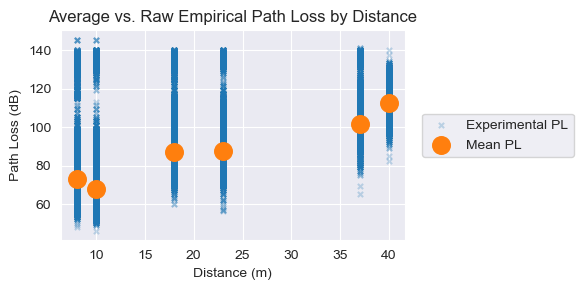

In [55]:
# Raw full-dataset view retained from the original empirical notebook.
sns.set_style("darkgrid")

avg_exp_pl = df_full.groupby("distance", as_index=False)[target_col].mean()

fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(df_full["distance"], df_full[target_col], marker="x", alpha=0.25, s=14, label="Experimental PL", zorder=1)
ax.scatter(avg_exp_pl["distance"], avg_exp_pl[target_col], marker="o", s=160, label="Mean PL", zorder=2)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Path Loss (dB)")
ax.set_title("Average vs. Raw Empirical Path Loss by Distance")
ax.legend(bbox_to_anchor=(1.05, 0.5), loc="center left", borderaxespad=0.0)
ax.grid(True)
plt.tight_layout()
plt.show()

#### 5-fold CV, held-out test evaluation, and final train refit


In [56]:
# Time-aware 5-fold CV on the prepared train split, followed by held-out test evaluation.

plm_results = []
fold_metric_rows = []
oof_predictions = {}
test_predictions = {}
full_predictions = {}

t0 = time.time()

for model_name, model_factory in plm_specs:
    y_pred_oof = np.full(len(y_train), np.nan, dtype=float)
    tr_rmse_list, val_rmse_list, tr_r2_list, val_r2_list = [], [], [], []

    for fold_id in fold_ids:
        val_idx = np.where(fold_assignments == fold_id)[0]
        tr_idx = np.where(fold_assignments != fold_id)[0]

        fold_model = model_factory().fit(X_train.iloc[tr_idx], y_train[tr_idx])

        y_tr_pred = fold_model.predict(X_train.iloc[tr_idx])
        y_val_pred = fold_model.predict(X_train.iloc[val_idx])
        y_pred_oof[val_idx] = y_val_pred

        fold_train_rmse, fold_train_r2 = rmse_r2(y_train[tr_idx], y_tr_pred)
        fold_val_rmse, fold_val_r2 = rmse_r2(y_train[val_idx], y_val_pred)

        tr_rmse_list.append(fold_train_rmse)
        val_rmse_list.append(fold_val_rmse)
        tr_r2_list.append(fold_train_r2)
        val_r2_list.append(fold_val_r2)

        fold_metric_rows.append({
            "model": model_name,
            "fold": int(fold_id),
            "train_rmse": float(fold_train_rmse),
            "train_r2": float(fold_train_r2),
            "val_rmse": float(fold_val_rmse),
            "val_r2": float(fold_val_r2),
            "n_train": int(len(tr_idx)),
            "n_val": int(len(val_idx)),
        })

    final_model = model_factory().fit(X_train, y_train)
    y_test_pred = final_model.predict(X_test)
    y_full_pred = final_model.predict(X_full)
    test_rmse, test_r2 = rmse_r2(y_test, y_test_pred)
    test_corr2 = corr2(y_test, y_test_pred)

    oof_predictions[model_name] = y_pred_oof
    test_predictions[model_name] = y_test_pred
    full_predictions[model_name] = y_full_pred
    df_full[final_model.prediction_col] = y_full_pred

    plm_results.append({
        "model": model_name,
        "factory": model_factory,
        "final_model": final_model,
        "prediction_col": final_model.prediction_col,
        "cv": {
            "rmse_train_mean": float(np.mean(tr_rmse_list)),
            "rmse_train_sd": float(np.std(tr_rmse_list)),
            "rmse_val_mean": float(np.mean(val_rmse_list)),
            "rmse_val_sd": float(np.std(val_rmse_list)),
            "r2_train_mean": float(np.mean(tr_r2_list)),
            "r2_train_sd": float(np.std(tr_r2_list)),
            "r2_val_mean": float(np.mean(val_r2_list)),
            "r2_val_sd": float(np.std(val_r2_list)),
        },
        "test": {
            "rmse": float(test_rmse),
            "r2": float(test_r2),
            "corr2": float(test_corr2),
        },
        "params": final_model.params(),
    })

t1 = time.time()
print(f"Done processing {len(plm_results)} empirical PLMs in {(t1 - t0) / 60:.2f} minutes.")

Done processing 5 empirical PLMs in 0.08 minutes.


#### Generalization tables and saved residual sets


In [57]:
# Generalization table and per-model residual/model artifacts.
# Fold metrics stay in memory only; no CV/generalization CSV is exported.

MODEL_FILE_TAGS = {
    "FSPL": "FSPL",
    "Log-distance": "LOG_DISTANCE",
    "Motley-Keenan": "MOTLEY_KEENAN",
    "COST 231 MWM": "COST231_MWM",
    "ITU-R P.1238": "ITU_R_P1238",
}

summary_rows = []
for result in plm_results:
    cv = result["cv"]
    te = result["test"]
    summary_rows.append({
        "model": result["model"],
        "cv_rmse_train_mean": cv["rmse_train_mean"],
        "cv_rmse_train_sd": cv["rmse_train_sd"],
        "cv_rmse_val_mean": cv["rmse_val_mean"],
        "cv_rmse_val_sd": cv["rmse_val_sd"],
        "cv_r2_train_mean": cv["r2_train_mean"],
        "cv_r2_train_sd": cv["r2_train_sd"],
        "cv_r2_val_mean": cv["r2_val_mean"],
        "cv_r2_val_sd": cv["r2_val_sd"],
        "test_rmse": te["rmse"],
        "test_r2": te["r2"],
        "test_corr2": te["corr2"],
    })

plm_generalization_table = (
    pd.DataFrame(summary_rows)
    .sort_values(["cv_rmse_val_mean", "cv_rmse_val_sd", "test_rmse", "model"])
    .reset_index(drop=True)
)

best_name = str(plm_generalization_table.loc[0, "model"])
best_result = next(result for result in plm_results if result["model"] == best_name)
best_model = best_result["final_model"]
plm_generalization_table.insert(1, "selected", plm_generalization_table["model"].eq(best_name))

print(f"Selected empirical PLM by CV validation RMSE: {best_name}")
display(plm_generalization_table)


def residual_frame(df_source, split, y_true, y_pred, model_label, row_ids, folds=None):
    frame = pd.DataFrame({
        "model": f"PLM_{MODEL_FILE_TAGS[model_label]}",
        "split": split,
        "row_id": row_ids.astype(int),
        "time": df_source.get("time", pd.Series(index=df_source.index, dtype=object)).values,
        "device_id": df_source["device_id"].values,
        "distance": df_source["distance"].values,
        "frequency": df_source["frequency"].values,
        "c_walls": df_source["c_walls"].values,
        "w_walls": df_source["w_walls"].values,
        "co2": df_source["co2"].values,
        "humidity": df_source["humidity"].values,
        "pm25": df_source["pm25"].values,
        "pressure": df_source["pressure"].values,
        "temperature": df_source["temperature"].values,
        "snr": df_source["snr"].values,
        "PL_true": y_true,
        "PL_pred": y_pred,
        "resid_db": y_true - y_pred,
    })
    if folds is not None:
        frame.insert(3, "fold", folds.astype(int))
    return frame


plm_oof_residuals_by_model = {}
plm_test_residuals_by_model = {}
plm_residual_paths = {}
plm_model_paths = {}

for result in plm_results:
    model_name = result["model"]
    tag = MODEL_FILE_TAGS[model_name]

    oof_pred_all = oof_predictions[model_name]
    oof_mask = ~np.isnan(oof_pred_all)
    if int(oof_mask.sum()) != len(df_train):
        print(f"{model_name}: OOF residuals generated for {int(oof_mask.sum()):,} of {len(df_train):,} train rows.")

    oof_df = residual_frame(
        df_train.loc[oof_mask].reset_index(drop=True),
        split="oof",
        y_true=y_train[oof_mask],
        y_pred=oof_pred_all[oof_mask],
        model_label=model_name,
        row_ids=np.arange(len(df_train), dtype=int)[oof_mask],
        folds=fold_assignments[oof_mask],
    )
    oof_path = os.path.join(RESIDUALS_DIR, f"residuals_PLM_{tag}_oof.csv")
    oof_df.to_csv(oof_path, index=False)

    test_pred = test_predictions[model_name]
    test_df = residual_frame(
        df_test.reset_index(drop=True),
        split="test",
        y_true=y_test,
        y_pred=test_pred,
        model_label=model_name,
        row_ids=np.arange(len(df_test), dtype=int),
    )
    test_path = os.path.join(RESIDUALS_DIR, f"residuals_PLM_{tag}_test.csv")
    test_df.to_csv(test_path, index=False)

    model_path = os.path.join(MODELS_DIR, f"plm_{tag}_model.json")
    model_artifact = {
        "model": model_name,
        "file_tag": tag,
        "target": target_col,
        "selected_by_cv": model_name == best_name,
        "params": result["params"],
        "formula_notes": {
            "fspl": "20 log10(4 pi d f / c), d in metres, f in Hz.",
            "motley_keenan": "FSPL plus fitted wall attenuation; no fitted constant loss.",
            "cost231_mwm": "FSPL plus fitted constant and wall attenuation; floor term omitted for same-floor data.",
            "itu_r_p1238": "20 log10(f_MHz) + N log10(d_m) + Lf(n) - 28; Lf=0 here.",
        },
    }
    with open(model_path, "w", encoding="utf-8") as f:
        json.dump(as_builtin(model_artifact), f, indent=2)

    plm_oof_residuals_by_model[model_name] = y_train[oof_mask] - oof_pred_all[oof_mask]
    plm_test_residuals_by_model[model_name] = y_test - test_pred
    plm_residual_paths[model_name] = {"oof": oof_path, "test": test_path}
    plm_model_paths[model_name] = model_path

print("Saved per-model OOF/test residuals:")
for model_name in model_labels:
    paths = plm_residual_paths[model_name]
    print(f"  {model_name}: {paths['oof']} | {paths['test']}")

print("Saved per-model PLM artifacts:")
for model_name in model_labels:
    print(f"  {model_name}: {plm_model_paths[model_name]}")

Selected empirical PLM by CV validation RMSE: COST 231 MWM


,model,selected,cv_rmse_train_mean,cv_rmse_train_sd,cv_rmse_val_mean,cv_rmse_val_sd,cv_r2_train_mean,cv_r2_train_sd,cv_r2_val_mean,cv_r2_val_sd,test_rmse,test_r2,test_corr2
0,COST 231 MWM,True,11.021933,0.271340,11.189399,1.025326,0.656488,0.017120,0.640789,0.067402,12.499467,0.559286,0.562339
1,Log-distance,False,11.776082,0.275810,11.957912,1.002401,0.607774,0.020960,0.587617,0.085189,12.190956,0.580773,0.582645
2,ITU-R P.1238,False,12.099718,0.207461,12.211081,0.747597,0.586093,0.016098,0.572888,0.062233,12.464541,0.561745,0.582629
3,Motley-Keenan,False,13.945413,0.340621,14.099757,1.287772,0.449996,0.028934,0.427154,0.124479,15.559833,0.317058,0.544192
4,FSPL,False,35.138497,0.165967,35.135171,0.842847,-2.489533,0.056837,-2.522598,0.289099,34.472063,-2.352035,0.582609


Saved per-model OOF/test residuals:
  FSPL: Residuals\residuals_PLM_FSPL_oof.csv | Residuals\residuals_PLM_FSPL_test.csv
  Log-distance: Residuals\residuals_PLM_LOG_DISTANCE_oof.csv | Residuals\residuals_PLM_LOG_DISTANCE_test.csv
  Motley-Keenan: Residuals\residuals_PLM_MOTLEY_KEENAN_oof.csv | Residuals\residuals_PLM_MOTLEY_KEENAN_test.csv
  COST 231 MWM: Residuals\residuals_PLM_COST231_MWM_oof.csv | Residuals\residuals_PLM_COST231_MWM_test.csv
  ITU-R P.1238: Residuals\residuals_PLM_ITU_R_P1238_oof.csv | Residuals\residuals_PLM_ITU_R_P1238_test.csv
Saved per-model PLM artifacts:
  FSPL: Models\plm_FSPL_model.json
  Log-distance: Models\plm_LOG_DISTANCE_model.json
  Motley-Keenan: Models\plm_MOTLEY_KEENAN_model.json
  COST 231 MWM: Models\plm_COST231_MWM_model.json
  ITU-R P.1238: Models\plm_ITU_R_P1238_model.json


#### Final fitted empirical parameters


In [58]:
# Parameter table for the train-refit empirical models.
param_rows = []
for result in plm_results:
    for param_name, param_value in result["params"].items():
        if param_name == "model":
            continue
        param_rows.append({
            "model": result["model"],
            "parameter": param_name,
            "value": param_value,
        })

plm_param_table = pd.DataFrame(param_rows)
def maybe_float(value):
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    return value

plm_param_table["value"] = plm_param_table["value"].map(maybe_float)
display(plm_param_table)

for result in plm_results:
    print(f"\n{result['model']} parameters")
    for key, value in result["params"].items():
        if key == "model":
            continue
        if isinstance(value, (int, float, np.integer, np.floating)):
            print(f"  {key}: {float(value):.4f}")
        else:
            print(f"  {key}: {value}")

,model,parameter,value
0,FSPL,c_m_per_s,2.997925e+08
1,Log-distance,b0_db,1.697140e+01
2,Log-distance,slope_db_per_decade,5.582562e+01
3,Log-distance,path_loss_exponent_n,5.582562e+00
4,Motley-Keenan,concrete_wall_loss_db,1.752997e+01
5,Motley-Keenan,wood_wall_loss_db,8.376975e+00
6,Motley-Keenan,extra_intercept_db,0.000000e+00
7,COST 231 MWM,constant_loss_db,1.578022e+01
8,COST 231 MWM,concrete_wall_loss_db,1.065036e+01
9,COST 231 MWM,wood_wall_loss_db,4.804771e+00



FSPL parameters
  c_m_per_s: 299792458.0000

Log-distance parameters
  b0_db: 16.9714
  slope_db_per_decade: 55.8256
  path_loss_exponent_n: 5.5826

Motley-Keenan parameters
  concrete_wall_loss_db: 17.5300
  wood_wall_loss_db: 8.3770
  extra_intercept_db: 0.0000

COST 231 MWM parameters
  constant_loss_db: 15.7802
  concrete_wall_loss_db: 10.6504
  wood_wall_loss_db: 4.8048
  floor_loss_db: 0.0000

ITU-R P.1238 parameters
  N_db_per_decade: 45.5099
  equivalent_path_loss_exponent_n: 4.5510
  floor_penetration_loss_db: 0.0000


#### Average path loss vs. empirical model fits
The visual comparison is still made over the full cleaned dataset for continuity with the original empirical analysis. Model curves are generated from final models fitted only on the train split, then averaged by distance.


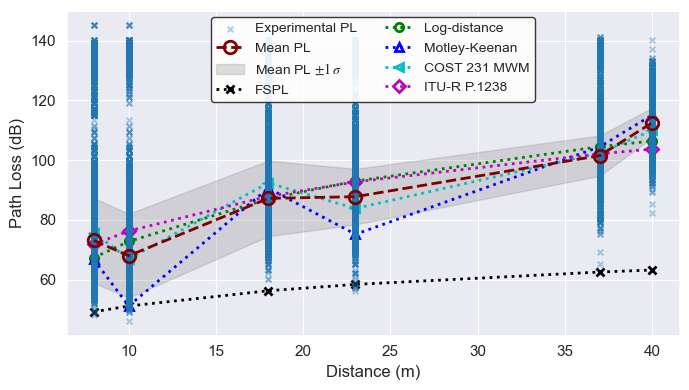

In [59]:
# Distance-aggregated plot data.
plot_summary = (
    df_full.groupby("distance")
    .agg(PL_mean=(target_col, "mean"), PL_std=(target_col, "std"))
    .reset_index()
    .sort_values("distance")
)
plot_summary["PL_lower"] = plot_summary["PL_mean"] - plot_summary["PL_std"].fillna(0.0)
plot_summary["PL_upper"] = plot_summary["PL_mean"] + plot_summary["PL_std"].fillna(0.0)

prediction_cols = {result["model"]: result["prediction_col"] for result in plm_results}
avg_predictions = {
    name: (
        df_full.groupby("distance", as_index=False)[pred_col]
        .mean()
        .sort_values("distance")
    )
    for name, pred_col in prediction_cols.items()
}

line_styles = {
    "FSPL": dict(marker="x", color="k", linestyle=":"),
    "Log-distance": dict(marker="o", color="g", linestyle=":"),
    "Motley-Keenan": dict(marker="^", color="b", linestyle=":"),
    "COST 231 MWM": dict(marker="<", color="c", linestyle=":"),
    "ITU-R P.1238": dict(marker="D", color="m", linestyle=":"),
}

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"
sns.set_style("darkgrid")

fig, ax = plt.subplots(figsize=(7, 4))
for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.scatter(df_full["distance"], df_full[target_col], marker="x", alpha=0.35, s=16, label="Experimental PL", zorder=4)
ax.plot(
    plot_summary["distance"], plot_summary["PL_mean"],
    marker="o", color="#800000", linestyle="--", markersize=9,
    linewidth=2, label="Mean PL", zorder=7, markerfacecolor="none", markeredgewidth=2.0,
)
ax.fill_between(
    plot_summary["distance"].to_numpy(dtype=float),
    plot_summary["PL_lower"].to_numpy(dtype=float),
    plot_summary["PL_upper"].to_numpy(dtype=float),
    color="gray", alpha=0.25, label=r"Mean PL $\pm 1\,\sigma$", zorder=1,
)

for name in model_labels:
    avg_pred = avg_predictions[name]
    pred_col = prediction_cols[name]
    style = line_styles[name]
    ax.plot(
        avg_pred["distance"], avg_pred[pred_col],
        label=name, markersize=6, linewidth=2, markerfacecolor="none",
        markeredgewidth=2.0, **style,
    )

ax.set_xlabel("Distance (m)", fontsize=12)
ax.set_ylabel("Path Loss (dB)", fontsize=12)
ax.tick_params(axis="both", labelsize=11)
legend = ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=2, fontsize=10, frameon=True)
legend.get_frame().set_facecolor("#ffffff")
legend.get_frame().set_alpha(0.9)
legend.get_frame().set_edgecolor("#222222")
legend.set_zorder(10)
ax.grid(True)
plt.tight_layout()
plt.show()

#### Residual CDFs from OOF or held-out residuals


Residual source: oof
Selected model: COST 231 MWM
n = 1,663,627
Mean residual: 0.0038 dB
Std residual:  11.0638 dB


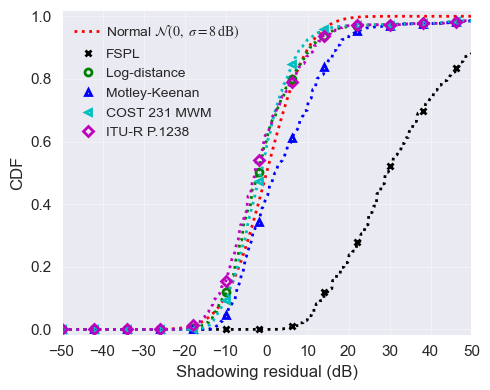

In [60]:
# Residual CDFs use out-of-fold train residuals by default to avoid in-sample optimism.
# Set RESIDUAL_SOURCE = "test" to show held-out residual distributions instead.
RESIDUAL_SOURCE = "oof"
REFERENCE_SIGMA_DB = 8.0

residual_sources = {
    "oof": plm_oof_residuals_by_model,
    "test": plm_test_residuals_by_model,
}
if RESIDUAL_SOURCE not in residual_sources:
    raise ValueError(f"RESIDUAL_SOURCE must be one of {list(residual_sources)}")

residuals_by_model = residual_sources[RESIDUAL_SOURCE]
selected_residuals = pd.Series(residuals_by_model[best_name], name=f"{best_name}_{RESIDUAL_SOURCE}_resid_db")

print(f"Residual source: {RESIDUAL_SOURCE}")
print(f"Selected model: {best_name}")
print(f"n = {len(selected_residuals):,}")
print(f"Mean residual: {selected_residuals.mean():.4f} dB")
print(f"Std residual:  {selected_residuals.std(ddof=1):.4f} dB")

shadow_range = np.linspace(-50.0, 50.0, 500)
cdf_norm = norm.cdf(shadow_range, loc=0.0, scale=REFERENCE_SIGMA_DB)


def empirical_cdf(values, x_grid):
    values_sorted = np.sort(np.asarray(values, dtype=float))
    return np.searchsorted(values_sorted, x_grid, side="right") / len(values_sorted)

cdf_by_model = {
    name: empirical_cdf(values, shadow_range)
    for name, values in residuals_by_model.items()
}

plt.figure(figsize=(5, 4))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

markspace = 40
markersize = 5
mew = 2.0

ax.plot(shadow_range, cdf_norm, linestyle=":", color="r", linewidth=2, label=fr"Normal $\mathcal{{N}}(0,\ \sigma={REFERENCE_SIGMA_DB:.0f}\,\mathrm{{dB}})$")
for name in model_labels:
    style = line_styles[name]
    cdf_values = cdf_by_model[name]
    ax.plot(
        shadow_range[::markspace], cdf_values[::markspace],
        linestyle="None", marker=style["marker"], color=style["color"],
        markerfacecolor="none", markersize=markersize, markeredgewidth=mew, label=name,
    )
    ax.plot(shadow_range, cdf_values, linestyle=style["linestyle"], color=style["color"], linewidth=2)

ax.set_xlabel("Shadowing residual (dB)", fontsize=12)
ax.set_ylabel("CDF", fontsize=12)
ax.set_xlim([-50, 50])
ax.set_ylim([-0.02, 1.02])
ax.set_xticks(np.arange(-50, 51, 10))
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.tick_params(axis="both", labelsize=11)
ax.grid(True, alpha=0.35)
ax.legend(frameon=False, fontsize=10, loc="upper left", handletextpad=0.3)
plt.tight_layout()
plt.show()

#### Combined empirical fit and residual CDF figure


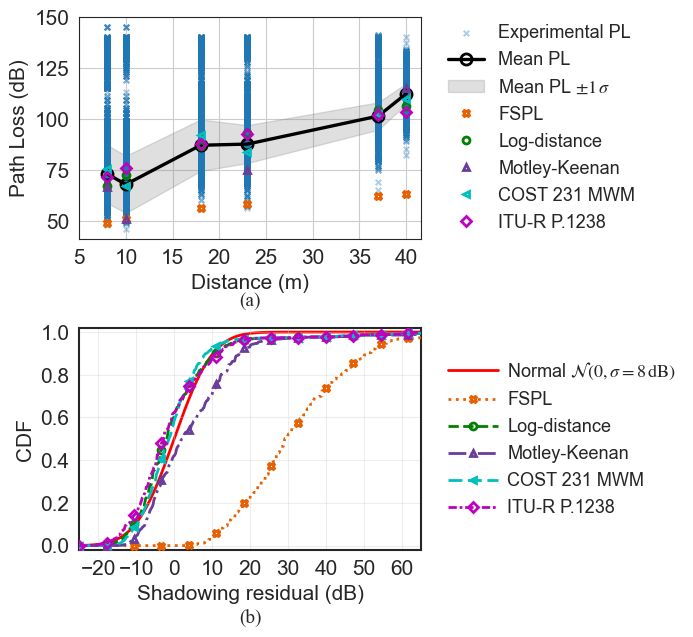

In [61]:
# Combined figure for reporting.
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

use_darkgrid = False
sns.set_style("darkgrid" if use_darkgrid else "white")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6.2))

tick_fontsize = 15
axis_labelsize = 15
legend_fontsize = 13
ab_fontsize = 14

ax2_xlim = [-25, 65]
markspace = 40
markersize = 5
mew = 2.0

shadow_range = np.linspace(ax2_xlim[0], ax2_xlim[1], 500)
cdf_norm = norm.cdf(shadow_range, loc=0.0, scale=REFERENCE_SIGMA_DB)

cdf_by_model = {
    name: empirical_cdf(values, shadow_range)
    for name, values in residuals_by_model.items()
}

plot_styles = {
    "FSPL": {"color": "#e66101", "marker": "X", "linestyle": ":"},
    "Log-distance": {"color": "green", "marker": "o", "linestyle": "--"},
    "Motley-Keenan": {"color": "#6a3d9a", "marker": "^", "linestyle": "-."},
    "COST 231 MWM": {"color": "c", "marker": "<", "linestyle": (0, (5, 2))},
    "ITU-R P.1238": {"color": "m", "marker": "D", "linestyle": (0, (3, 1, 1, 1))},
}

# (a) Path loss vs distance.
ax1.fill_between(plot_summary["distance"].to_numpy(dtype=float),
                 plot_summary["PL_lower"].to_numpy(dtype=float),
                 plot_summary["PL_upper"].to_numpy(dtype=float),
                 color="gray", alpha=0.25, label=r"Mean PL $\pm 1\,\sigma$", zorder=1)

ax1.scatter(df_full["distance"], df_full[target_col], marker="x", alpha=0.35, s=16,
            label="Experimental PL", zorder=3)

ax1.plot(plot_summary["distance"], plot_summary["PL_mean"], marker="o", color="black",
         linestyle="-", markersize=8, linewidth=2.4, label="Mean PL",
         zorder=4, markerfacecolor="none", markeredgewidth=2.0)

for name in model_labels:
    avg_pred = avg_predictions[name]
    pred_col = prediction_cols[name]
    style = plot_styles[name]

    ax1.plot(avg_pred["distance"], avg_pred[pred_col], linestyle="None",
             marker=style["marker"], color=style["color"], label=name,
             markersize=5, markerfacecolor="none", markeredgewidth=2.0, zorder=7)

ax1.set_xlabel("Distance (m)", fontsize=axis_labelsize)
ax1.set_ylabel("Path Loss (dB)", fontsize=axis_labelsize)
ax1.set_xticks(np.arange(5, 41, 5))
ax1.set_yticks(np.arange(50, 151, 25))
ax1.tick_params(axis="both", labelsize=tick_fontsize)
ax1.grid(True)

handles1, labels1 = ax1.get_legend_handles_labels()
legend1_order = ["Experimental PL", "Mean PL", r"Mean PL $\pm 1\,\sigma$"] + model_labels
label_to_handle1 = {label: handle for handle, label in zip(handles1, labels1)}
legend1 = ax1.legend([label_to_handle1[label] for label in legend1_order], legend1_order,
                     loc="center left", bbox_to_anchor=(1.03, 0.5), ncol=1,
                     fontsize=legend_fontsize, frameon=False)
legend1.set_zorder(10)

# (b) Residual CDFs.
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)

ax2.plot(shadow_range, cdf_norm, linestyle="-", color="r", linewidth=2,
         label=fr"Normal $\mathcal{{N}}(0, \sigma={REFERENCE_SIGMA_DB:.0f}\,\mathrm{{dB}})$", zorder=0)

for name in model_labels:
    style = plot_styles[name]
    cdf_values = cdf_by_model[name]

    ax2.plot(shadow_range, cdf_values, linestyle=style["linestyle"], color=style["color"], linewidth=2,
             marker=style["marker"], markevery=markspace, markerfacecolor="none",
             markersize=markersize, markeredgewidth=mew, label=name, zorder=3)

ax2.set_xlabel("Shadowing residual (dB)", fontsize=axis_labelsize)
ax2.set_ylabel("CDF", fontsize=axis_labelsize)
ax2.set_xlim(ax2_xlim)
ax2.set_ylim([-0.02, 1.02])
#ax2.set_xticks(np.arange(ax2_xlim[0], ax2_xlim[1] + 1, 10))
ax2.set_xticks(np.arange(-20, 61, 10))   # includes 0 for reference
ax2.set_yticks(np.arange(0, 1.1, 0.2))
ax2.tick_params(axis="both", labelsize=tick_fontsize)
ax2.grid(True, alpha=0.35)

legend2 = ax2.legend(loc="center left", bbox_to_anchor=(1.03, 0.5), ncol=1,
                     fontsize=legend_fontsize, frameon=False,
                     handlelength=2.8, handletextpad=0.5)
legend2.set_zorder(10)

fig.subplots_adjust(left=0.13, right=0.70, top=0.96, bottom=0.10, hspace=0.40)

pos1 = ax1.get_position()
pos2 = ax2.get_position()
cap_x = (pos1.x0 + pos1.x1) / 2

fig.text(cap_x, pos1.y0 - 0.085, "(a)", ha="center", va="top",
         fontsize=ab_fontsize, fontfamily="Times New Roman")

fig.text(cap_x, pos2.y0 - 0.095, "(b)", ha="center", va="top",
         fontsize=ab_fontsize, fontfamily="Times New Roman")

plt.savefig(FIGURE_PATH, dpi=1200, bbox_inches="tight")
plt.show()